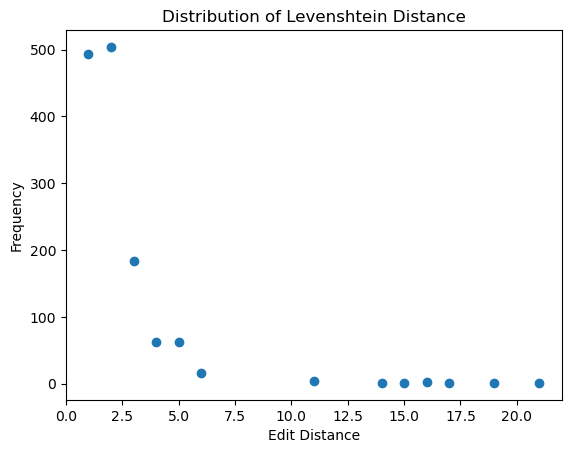

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_levenshtein_distribution(csv_path, col_name="Lev_Dist"):
    df = pd.read_csv(csv_path)

    if col_name not in df.columns:
        raise ValueError(f"Column '{col_name}' not found in CSV.")

    # Convert to numeric safely
    values = pd.to_numeric(df[col_name], errors="coerce").dropna()
    freq = values.value_counts().sort_index()
    plt.figure()
    plt.scatter(freq.index, freq.values)
    plt.title("Distribution of Levenshtein Distance")
    plt.xlabel("Edit Distance")
    plt.ylabel("Frequency")
    plt.show()

plot_levenshtein_distribution("rows_with_no_equality.csv")

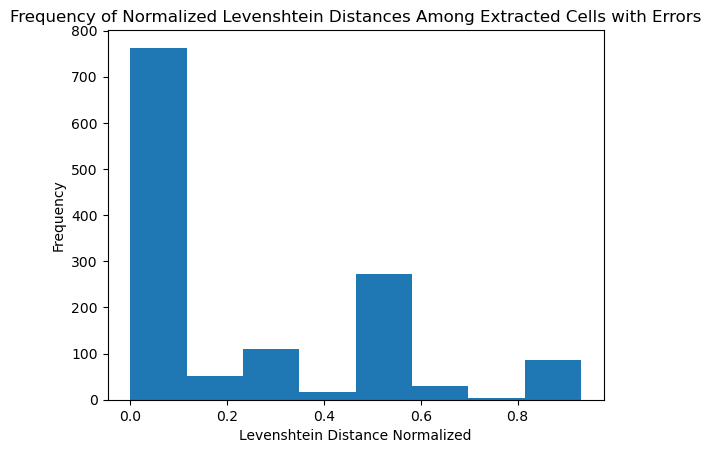

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

import pandas as pd
import matplotlib.pyplot as plt

def plot_lev_dist_frequency(csv_path, col_name="Lev_Dist"):
    df = pd.read_csv(csv_path)

    if col_name not in df.columns:
        raise ValueError(f"Column '{col_name}' not found.")

    # Convert to numeric and drop bad values
    vals = pd.to_numeric(df[col_name], errors="coerce").dropna()

    # Count frequency of each distance
    freq = vals.value_counts().sort_index()

    plt.figure()
    plt.title("Frequency of Normalized Levenshtein Distances Among Extracted Cells with Errors")
    plt.hist(vals, bins=8)

    plt.xlabel("Levenshtein Distance Normalized")
    plt.ylabel("Frequency")
    plt.show()
plot_lev_dist_frequency("rows_with_no_equality.csv", "Lev_Sim")

In [6]:
import pandas as pd

df = pd.read_csv("rows_with_no_equality.csv")

# Replace these
column_name = "Lev_Dist"
value_to_match = 20

# Print matching rows
print(df[df[column_name] >= value_to_match])




                                            file_name  row_index  col_index  \
683  padded_cdi_ca_1956_wk_prov_dbs_Part28_tables.csv         26          1   

     AWS_Value                   Manual_Value  Equal  \
683  diseases⁷  (e) Other venereal diseases 8  False   

     Equal_No_Commas_No_Spaces  Equal_Shifted  Only_Numbers_Equal_Or_Shifted  \
683                      False          False                          False   

     Any_Equality Confidence_Value  Lev_Dist   Lev_Sim  
683         False             87.3        21  0.275862  


Min: 1 Max: 21


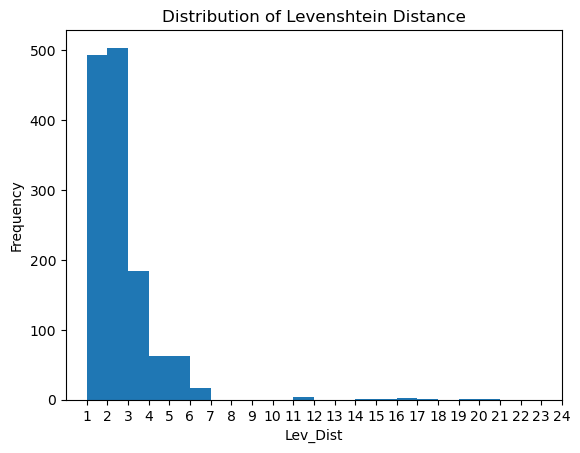

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("rows_with_no_equality.csv")

vals = pd.to_numeric(df["Lev_Dist"], errors="coerce").dropna()

print("Min:", vals.min(), "Max:", vals.max())

plt.figure()
plt.hist(vals, bins=20)
plt.title("Distribution of Levenshtein Distance")
plt.xlabel("Lev_Dist")
plt.ylabel("Frequency")
plt.xticks(np.arange(1,25,1))

plt.show()


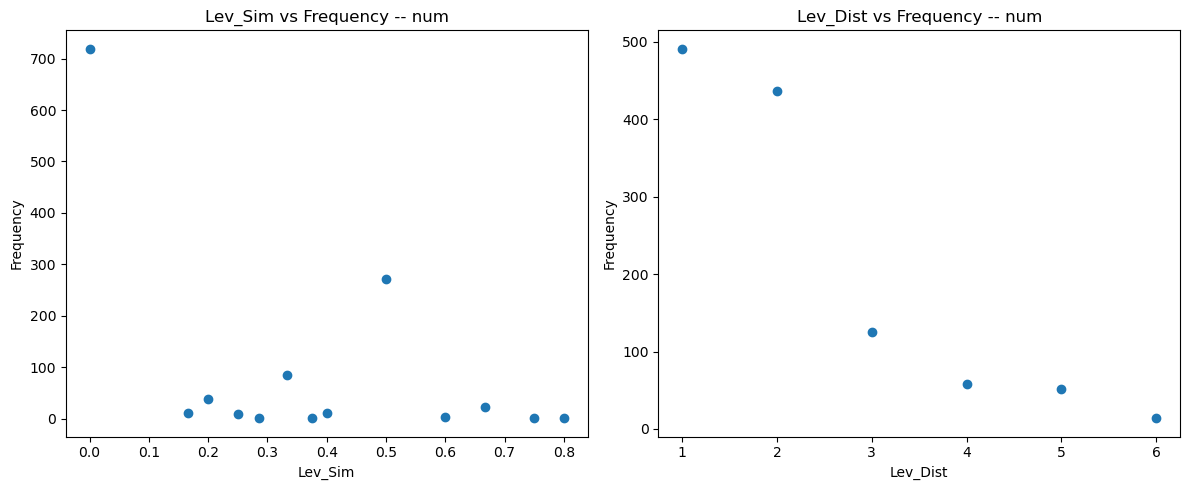

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_sim_and_dist_side_by_side(csv_path):
    df = pd.read_csv(csv_path)

    # Convert safely to numeric
    sim = pd.to_numeric(df["Lev_Sim"], errors="coerce").dropna()
    dist = pd.to_numeric(df["Lev_Dist"], errors="coerce").dropna()

    # Frequency counts
    sim_freq = sim.value_counts().sort_index()
    dist_freq = dist.value_counts().sort_index()

    # Create side-by-side plots
    plt.figure(figsize=(12, 5))

    # Left plot: Lev_Sim frequency
    plt.subplot(1, 2, 1)
    plt.scatter(sim_freq.index, sim_freq.values)
    plt.title("Lev_Sim vs Frequency -- num")
    plt.xlabel("Lev_Sim")
    plt.ylabel("Frequency")

    # Right plot: Lev_Dist frequency
    plt.subplot(1, 2, 2)
    plt.scatter(dist_freq.index, dist_freq.values)
    plt.title("Lev_Dist vs Frequency -- num")
    plt.xlabel("Lev_Dist")
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()
plot_sim_and_dist_side_by_side("rows_numeric_decimal_space_comma.csv")

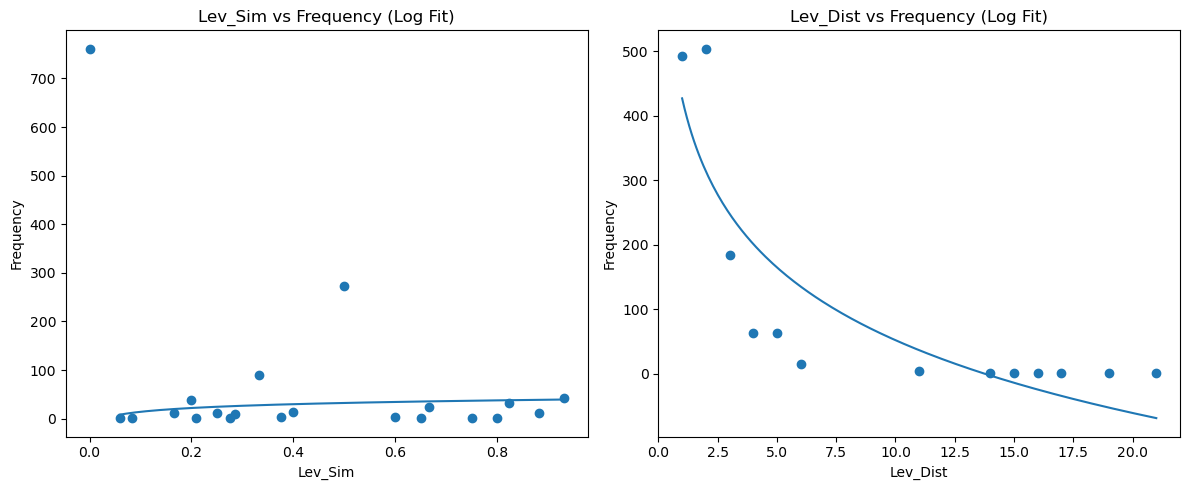

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

def plot_sim_and_dist_side_by_side(csv_path):
    df = pd.read_csv(csv_path)

    # Convert safely to numeric
    sim = pd.to_numeric(df["Lev_Sim"], errors="coerce").dropna()
    dist = pd.to_numeric(df["Lev_Dist"], errors="coerce").dropna()

    # Frequency counts
    sim_freq = sim.value_counts().sort_index()
    dist_freq = dist.value_counts().sort_index()

    # Log model
    def log_fit(x, a, b):
        return a * np.log(x) + b

    plt.figure(figsize=(12, 5))

    # ---------------- Left: Lev_Sim ----------------
    plt.subplot(1, 2, 1)
    plt.scatter(sim_freq.index, sim_freq.values)

    x1 = sim_freq.index.values.astype(float)
    y1 = sim_freq.values.astype(float)

    # Remove zeros (log not defined)
    mask1 = x1 > 0
    x1 = x1[mask1]
    y1 = y1[mask1]

    # Fit curve
    params1, _ = curve_fit(log_fit, x1, y1)
    x1_smooth = np.linspace(min(x1), max(x1), 200)
    y1_smooth = log_fit(x1_smooth, *params1)

    plt.plot(x1_smooth, y1_smooth)
    plt.title("Lev_Sim vs Frequency (Log Fit)")
    plt.xlabel("Lev_Sim")
    plt.ylabel("Frequency")

    # ---------------- Right: Lev_Dist ----------------
    plt.subplot(1, 2, 2)
    plt.scatter(dist_freq.index, dist_freq.values)

    x2 = dist_freq.index.values.astype(float)
    y2 = dist_freq.values.astype(float)

    mask2 = x2 > 0
    x2 = x2[mask2]
    y2 = y2[mask2]

    params2, _ = curve_fit(log_fit, x2, y2)
    x2_smooth = np.linspace(min(x2), max(x2), 200)
    y2_smooth = log_fit(x2_smooth, *params2)

    plt.plot(x2_smooth, y2_smooth)
    plt.title("Lev_Dist vs Frequency (Log Fit)")
    plt.xlabel("Lev_Dist")
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()
plot_sim_and_dist_side_by_side("rows_with_no_equality.csv")

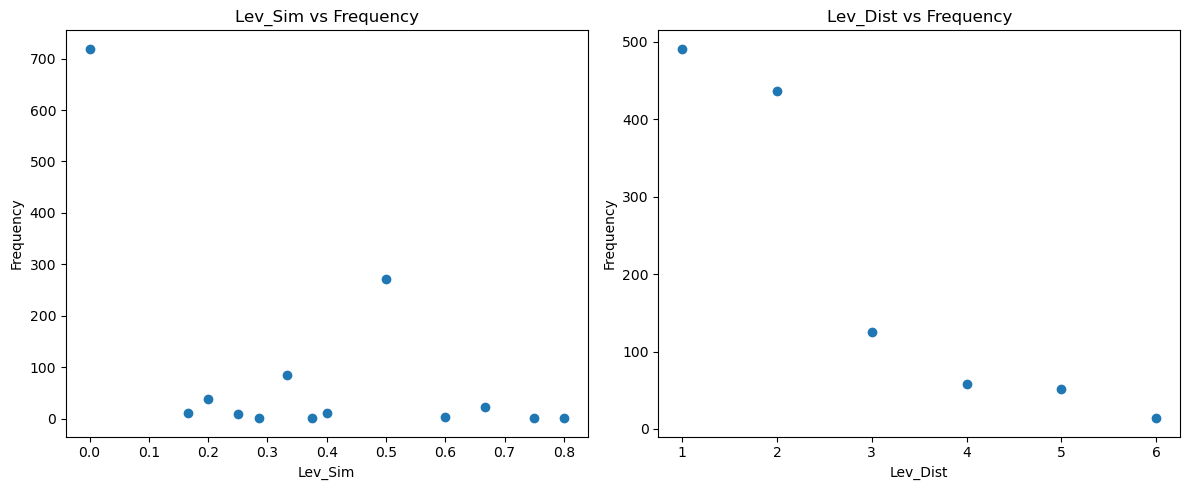

In [28]:
plot_sim_and_dist_side_by_side("rows_numeric_decimal_space_comma.csv")

In [16]:
import pandas as pd
import numpy as np

def add_numeric_diff(csv_path, col1, col2, output_path=None):
    """
    Reads a CSV, computes the row-wise numeric difference between two columns
    (col1 - col2) only when BOTH values are numbers.
    
    Parameters:
        csv_path (str): path to input CSV
        col1 (str): name of first column
        col2 (str): name of second column
        output_path (str, optional): save updated CSV if provided
    
    Returns:
        pandas.DataFrame: DataFrame with added 'numeric_diff' column
    """
    df = pd.read_csv(csv_path)

    # Convert to numeric, invalid values become NaN
    c1 = pd.to_numeric(df[col1], errors='coerce')
    c2 = pd.to_numeric(df[col2], errors='coerce')

    # Compute diff only where both are numeric
    df["numeric_diff"] = np.where(
        c1.notna() & c2.notna(),
        c1 - c2,
        np.nan
    )
    df["numeric_ratio"] = np.where(
        c1.notna() & c2.notna(),
        c1 / c2,
        np.nan
    )

    if output_path:
        df.to_csv(output_path, index=False)

    return df
add_numeric_diff("rows_numeric_decimal_space_comma.csv", "Manual_Value", "AWS_Value", "rows_with_numeric_diff.csv")

,file_name,row_index,col_index,AWS_Value,Manual_Value,Equal,Equal_No_Commas_No_Spaces,Equal_Shifted,Only_Numbers_Equal_Or_Shifted,Any_Equality,Confidence_Value,Lev_Dist,Lev_Sim,numeric_diff,numeric_ratio
0,padded_cdi_ca_1956_wk_prov_dbs_Part10_tables.csv,4,35,5,6,False,False,False,False,False,87.26,1,0.000000,1.0,1.200000
1,padded_cdi_ca_1956_wk_prov_dbs_Part10_tables.csv,6,38,61,7,False,False,False,False,False,85.60,2,0.000000,-54.0,0.114754
2,padded_cdi_ca_1956_wk_prov_dbs_Part10_tables.csv,8,38,1,9,False,False,False,False,False,82.37,1,0.000000,8.0,9.000000
3,padded_cdi_ca_1956_wk_prov_dbs_Part10_tables.csv,13,22,33,38,False,False,False,False,False,51.86,1,0.500000,5.0,1.151515
4,padded_cdi_ca_1956_wk_prov_dbs_Part10_tables.csv,14,38,77,15,False,False,False,False,False,85.94,2,0.000000,-62.0,0.194805
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1171,padded_cdi_ca_1956_wk_prov_dbs_Part9_tables.csv,9,34,.... 48,48,False,False,False,False,False,40.28,5,0.285714,NaN,NaN
1172,padded_cdi_ca_1956_wk_prov_dbs_Part9_tables.csv,9,38,9 10,10,False,False,False,False,False,72.51,2,0.500000,NaN,NaN
1173,padded_cdi_ca_1956_wk_prov_dbs_Part9_tables.csv,12,4,7,1,False,False,False,False,False,86.82,1,0.000000,-6.0,0.142857
1174,padded_cdi_ca_1956_wk_prov_dbs_Part9_tables.csv,14,30,7,1,False,False,False,False,False,74.66,1,0.000000,-6.0,0.142857


In [4]:
# How far off is the numeric value?
# relative error= abs(a-b)/max(abs(a),abs(b))


import numpy as np
import pandas as pd

def add_relative_error(csv_path, col1, col2):
    df = pd.read_csv(csv_path)

    a = pd.to_numeric(df[col1], errors='coerce')
    b = pd.to_numeric(df[col2], errors='coerce')

    df["relative_error"] = np.where(
        (a.notna() & b.notna()),
        np.abs(a - b) / np.maximum(a.abs(), b.abs()),
        np.nan
    )

    return df
df = add_relative_error("rows_with_numeric_diff.csv", "Manual_Value", "AWS_Value")
df.to_csv("rows_with_numeric_diff.csv", index=False)

In [3]:
#Is the magnitude (decimal placement) wrong?
# log difference = abs(log10(a) - log10(b))
'''
→ log10(1.33) ≈ 0.12
→ log10(133) ≈ 2.12
→ difference = 2 → exactly 2 digits / decimal places off.'''
import pandas as pd
import numpy as np

def add_log_diff(csv_path, col1, col2):
    df = pd.read_csv(csv_path)

    a = pd.to_numeric(df[col1], errors='coerce')
    b = pd.to_numeric(df[col2], errors='coerce')

    # valid conditions: strictly positive
    valid = (a > 0) & (b > 0)

    # initialize column
    df["log10_diff"] = np.nan

    # safe log10 only on valid rows
    df.loc[valid, "log10_difference"] = np.abs(np.log10(a[valid]) - np.log10(b[valid]))

    return df

df = add_log_diff("rows_numeric_decimal_space_comma.csv", "Manual_Value", "AWS_Value")
df.to_csv("rows_with_numeric_diff.csv", index=False)


In [7]:
# extract rows that are mostly character values
import pandas as pd
import re

def extract_mostly_non_numeric(csv_path, col1, col2, out_path=None):
    df = pd.read_csv(csv_path)

    def non_numeric_ratio(x):
        if pd.isna(x):
            return 1  # treat NaN as fully non-numeric
        s = str(x)
        digits = re.sub(r'\D', '', s)  # keep only digits
        if len(s.strip()) == 0:
            return 1
        return 1 - (len(digits) / len(s))  # ratio of non-digit characters

    ratio1 = df[col1].map(non_numeric_ratio)
    ratio2 = df[col2].map(non_numeric_ratio)

    # Keep rows where EITHER column is majority non-numeric (> 0.5)
    mask = (ratio1 > 0.5) | (ratio2 > 0.5)
    result = df[mask].copy()

    if out_path:
        result.to_csv(out_path, index=False)

    return result
extract_mostly_non_numeric("rows_with_no_equality.csv", "Manual_Value", "AWS_Value", "rows_strings.csv")

,file_name,row_index,col_index,AWS_Value,Manual_Value,Equal,Equal_No_Commas_No_Spaces,Equal_Shifted,Only_Numbers_Equal_Or_Shifted,Any_Equality,Confidence_Value,Lev_Dist,Lev_Sim
5,padded_cdi_ca_1956_wk_prov_dbs_Part10_tables.csv,16,1,Tuberculosis:4,"Tuberculosis: 4,6",False,False,False,False,False,81.25,3,0.823529
6,padded_cdi_ca_1956_wk_prov_dbs_Part10_tables.csv,26,1,(e) Other venereal diseases⁷,(e) Other venereal diseases 8,False,False,False,False,False,93.26,2,0.931034
9,padded_cdi_ca_1956_wk_prov_dbs_Part11_tables.csv,7,32,-- 10,10,False,False,False,False,False,72.75,3,0.400000
10,padded_cdi_ca_1956_wk_prov_dbs_Part11_tables.csv,9,34,P.O. 19,19,False,False,False,False,False,64.6,5,0.285714
14,padded_cdi_ca_1956_wk_prov_dbs_Part11_tables.csv,26,1,(e) Other venereal diseases⁷,(e) Other venereal diseases 8,False,False,False,False,False,88.82,2,0.931034
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1323,padded_cdi_ca_1956_wk_prov_dbs_Part9_tables.csv,7,34,.... 130,130,False,False,False,False,False,45.83,5,0.375000
1326,padded_cdi_ca_1956_wk_prov_dbs_Part9_tables.csv,9,34,.... 48,48,False,False,False,False,False,40.28,5,0.285714
1331,padded_cdi_ca_1956_wk_prov_dbs_Part9_tables.csv,21,32,R.P. 50,50,False,False,False,False,False,74.02,5,0.285714
1332,padded_cdi_ca_1956_wk_prov_dbs_Part9_tables.csv,21,34,A.P. 47,47,False,False,False,False,False,47.58,5,0.285714


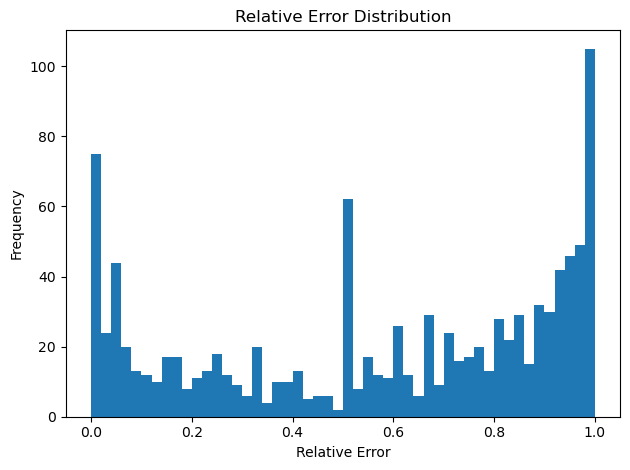

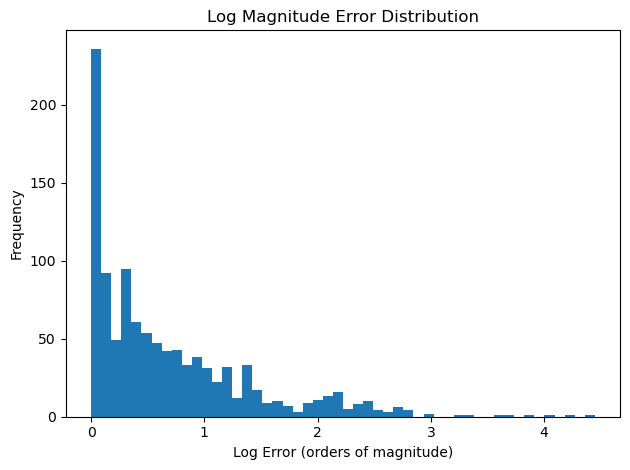

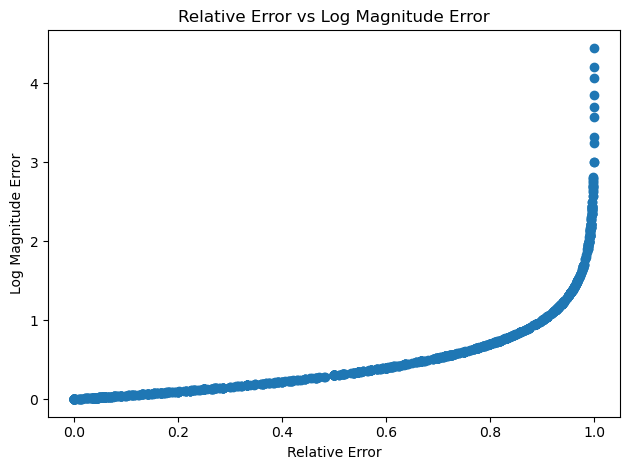

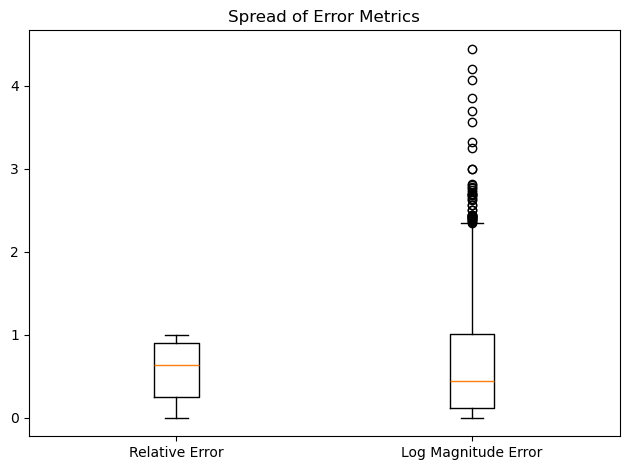

103 0.09671361502347418


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
CSV_PATH = "rows_with_numeric_diff.csv"  # path to your CSV file
REL_COL = "relative_error"        # column name for relative error
LOG_COL = "log10_difference"             # column name for log magnitude error
# e.g. if you called it "log10_diff", then:
# LOG_COL = "log10_diff"
# ==============================================



def load_and_clean(csv_path, rel_col, log_col):
    """Load CSV and coerce the two error columns to numeric."""
    df = pd.read_csv(csv_path)

    df[rel_col] = pd.to_numeric(df[rel_col], errors="coerce")
    df[log_col] = pd.to_numeric(df[log_col], errors="coerce")

    # drop rows where either metric is missing
    df = df.dropna(subset=[rel_col, log_col]).copy()

    return df


def plot_histograms(df, rel_col, log_col):
    """Histograms for each error metric."""
    # Relative error histogram
    plt.figure()
    plt.hist(df[rel_col], bins=50)
    plt.title("Relative Error Distribution")
    plt.xlabel("Relative Error")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

    # Log error histogram
    plt.figure()
    plt.hist(df[log_col], bins=50)
    plt.title("Log Magnitude Error Distribution")
    plt.xlabel("Log Error (orders of magnitude)")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()


def plot_scatter(df, rel_col, log_col):
    """Scatter: relative error vs log error."""
    plt.figure()
    plt.scatter(df[rel_col], df[log_col])
    plt.xlabel("Relative Error")
    plt.ylabel("Log Magnitude Error")
    plt.title("Relative Error vs Log Magnitude Error")
    plt.tight_layout()
    plt.show()




def plot_boxplot(df, rel_col, log_col):
    """Boxplot comparing spread of both metrics."""
    plt.figure()
    plt.boxplot(
        [df[rel_col].values, df[log_col].values],
        labels=["Relative Error", "Log Magnitude Error"],
    )
    plt.title("Spread of Error Metrics")
    plt.tight_layout()
    plt.show()

# show all plots
df = load_and_clean(CSV_PATH, REL_COL, LOG_COL)
plot_histograms(df, REL_COL, LOG_COL)
plot_scatter(df, REL_COL, LOG_COL)
plot_boxplot(df, REL_COL, LOG_COL)




decimals = df[df["log10_difference"].round() == 2]
print(len(decimals), len(decimals)/len(df))



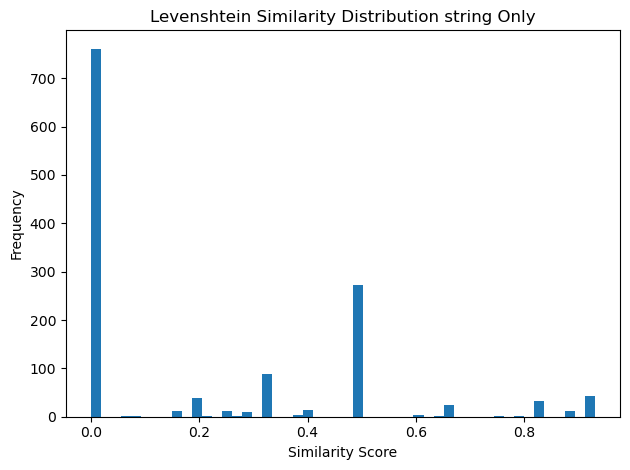

count    1334.000000
mean        0.214998
std         0.280762
min         0.000000
25%         0.000000
50%         0.000000
75%         0.500000
max         0.931034
Name: Lev_Sim, dtype: float64


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def plot_lev_similarity_hist(csv_path, col="Lev_Sim"):
    df = pd.read_csv(csv_path)

    # Force numeric
    sim = pd.to_numeric(df[col], errors="coerce").dropna()

    plt.figure()
    plt.hist(sim, bins=50)
    plt.title("Levenshtein Similarity Distribution string Only")
    plt.xlabel("Similarity Score")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

    print(sim.describe())
plot_lev_similarity_hist("rows_with_no_equality.csv", "Lev_Sim")